In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

# Definition and Justification of 3 KPI's for a Dashboard of a Hub Controller

## 1. Utilization Rate (%)
Displays the current utilization rate of the 2 charging sites. With this information, a hub controller can observe the availabilty of the current stations and can be warned if a site is fully used, which could lead to a loss of customers because no free charging spot is available.

## 2. Average Session Duration 
Displays the current average session duration at the 2 charging sites. Useful for pattern identification and a better understanding of the current hub situation.

## 3. Energy Delivered per Hour
Displays the delivered energy per hour, which can be used for resource planning and allocation.

In [21]:
data = pd.read_csv("data/cleaned_chargingdata.csv")

In [22]:
data['id'] = data['id'].astype('string')

data['connectionTime'] = pd.to_datetime(data['connectionTime'], errors='coerce', utc=True)  
data['disconnectTime'] = pd.to_datetime(data['disconnectTime'], errors='coerce', utc=True)  
data['doneChargingTime'] = pd.to_datetime(data['doneChargingTime'], errors='coerce', utc=True) 

data['sessionID'] = data['sessionID'].astype('string')
data['siteID'] = data['siteID'].astype('string')
data['spaceID'] = data['spaceID'].astype('string')
data['stationID'] = data['stationID'].astype('string')
data['timezone'] = data['timezone'].astype('string')
data['userID'] = data['userID'].astype('string')

In [23]:

data['connectionTime'] = data['connectionTime'].dt.tz_convert('America/Los_Angeles')
data['disconnectTime'] = data['disconnectTime'].dt.tz_convert('America/Los_Angeles')
data['doneChargingTime'] = data['doneChargingTime'].dt.tz_convert('America/Los_Angeles')

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64994 entries, 0 to 64993
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype                              
---  ------            --------------  -----                              
 0   Unnamed: 0.1      64994 non-null  int64                              
 1   Unnamed: 0        64994 non-null  int64                              
 2   id                64994 non-null  string                             
 3   connectionTime    64994 non-null  datetime64[ns, America/Los_Angeles]
 4   disconnectTime    64994 non-null  datetime64[ns, America/Los_Angeles]
 5   doneChargingTime  60907 non-null  datetime64[ns, America/Los_Angeles]
 6   kWhDelivered      64994 non-null  float64                            
 7   sessionID         64994 non-null  string                             
 8   siteID            64994 non-null  string                             
 9   spaceID           64994 non-null  string                     

In [25]:
data_site_1 = data[data['siteID'] == 1].copy()
data_site_2 = data[data['siteID'] == 2].copy()

In [ ]:
min_date_1 = min(data_site_1['connectionDate'].min(), data_site_1['disconnectDate'].min())
max_date_1 = max(data_site_1['connectionDate'].max(), data_site_1['disconnectDate'].max())

min_date_2 = min(data_site_2['connectionDate'].min(), data_site_2['disconnectDate'].min())
max_date_2 = max(data_site_2['connectionDate'].max(), data_site_2['disconnectDate'].max())


In [ ]:
# Create a complete list of all days in the range for SiteID 1
all_days_1 = pd.date_range(start=min_date_1, end=max_date_1).date

# Create a complete list of all days in the range for SiteID 2
all_days_2 = pd.date_range(start=min_date_2, end=max_date_2).date

## 1. Utilization Rate

In [33]:
# data['hour'] = data['connectionTime'].dt.hour
# data['date_hour'] = data['connectionTime'].dt.floor('H')
# total_chargers = data['stationID'].nunique()
#datakpi = data.copy()
print(data['siteID'].dtype)  # Check the data type of siteID column
#print(type(site_id))        # Check the type of site_id variable


string


In [34]:
def calculate_hourly_utilization_rate(site_id, data):
    """
    Calculate the hourly utilization rate for a charging site without considering inactive days.
    """
    site_id = str(site_id)  # Convert site_id to string
    # Debugging: Check the input data
    print(f"Number of rows in the input data: {len(data)}")
    print(f"Columns in the input data: {list(data.columns)}")

    # Ensure datetime format
    data['connectionTime'] = pd.to_datetime(data['connectionTime'], errors='coerce')
    data['disconnectTime'] = pd.to_datetime(data['disconnectTime'], errors='coerce')

    # Remove invalid rows
    data = data.dropna(subset=['connectionTime', 'disconnectTime'])
    data = data[data['connectionTime'] <= data['disconnectTime']]

    # Filter data for the given site
    site_data = data[data['siteID'] == site_id].copy()
    print(f"Number of rows for siteID {site_id}: {len(site_data)}")

    # Ensure site_data is not empty
    if site_data.empty:
        print(f"No data found for siteID {site_id}.")
        return pd.DataFrame()

    # Get the number of unique charging stations
    num_stations = site_data['stationID'].nunique()
    print(f"Number of stations: {num_stations}")

    # Generate hourly data from charging sessions
    hourly_data = []
    for _, row in site_data.iterrows():
        start_time = row['connectionTime'].floor('H')
        end_time = row['disconnectTime'].floor('H')
        current_time = start_time

        while current_time <= end_time:
            hourly_data.append({
                'stationID': row['stationID'],
                'connectionDate': current_time.date(),
                'hour': current_time.hour,
                'active_charging': 1
            })
            current_time += pd.Timedelta(hours=1)

    # Create a DataFrame for hourly usage
    hourly_usage_df = pd.DataFrame(hourly_data)

    # Check if hourly data was generated
    if hourly_usage_df.empty:
        print("No hourly data generated. Check the input data.")
        return pd.DataFrame()

    # Remove duplicates
    hourly_usage_df = hourly_usage_df.drop_duplicates()

    # Aggregate usage by hour
    hourly_usage = hourly_usage_df.groupby('hour')['active_charging'].sum().reset_index()

    # Calculate utilization rate
    total_active_days = site_data['connectionTime'].dt.date.nunique()
    hourly_usage['utilization_rate'] = (
        hourly_usage['active_charging'] / (total_active_days * num_stations) * 100
    )

    return hourly_usage


In [27]:
def plot_hourly_utilization(hourly_usage_site1, hourly_usage_site2=None, title="Hourly Utilization Over Time"):
    """
    Plots hourly utilization rates for one or two sites.

    Parameters:
        hourly_usage_site1 (pd.DataFrame): DataFrame with 'hour' and 'utilization_rate' columns for Site 1.
        hourly_usage_site2 (pd.DataFrame, optional): DataFrame with 'hour' and 'utilization_rate' columns for Site 2.
        title (str): Title of the plot.
    """
    plt.figure(figsize=(12, 6))

    # Plot Site 1
    plt.plot(
        hourly_usage_site1['hour'], 
        hourly_usage_site1['utilization_rate'], 
        label='Utilization Rate Site 1', 
        marker='o', 
        color='blue'
    )

    # Plot Site 2 (if provided)
    if hourly_usage_site2 is not None:
        plt.plot(
            hourly_usage_site2['hour'], 
            hourly_usage_site2['utilization_rate'], 
            label='Utilization Rate Site 2', 
            marker='o', 
            color='green'
        )

    # Add horizontal line for max capacity (100%)
    plt.axhline(y=100, color='red', linestyle='--', label='Max Capacity (100%)')

    # Title and labels
    plt.title(title)
    plt.xlabel('Hour of the Day')
    plt.ylabel('Utilization Rate (%)')

    # Set X-axis ticks (for each hour)
    plt.xticks(range(24), labels=[f"{h}:00" for h in range(24)], rotation=45)

    # Add grid, legend, and display
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.show()

In [35]:
# Example usage
avg_hourly_usage_site1 = calculate_hourly_utilization_rate(
    '1',
    data  # DataFrame with charging session data
)

avg_hourly_usage_site2 = calculate_hourly_utilization_rate(
    '2',
    data
)

# Display or analyze results
print(avg_hourly_usage_site1)
print(avg_hourly_usage_site2)


Number of rows in the input data: 64994
Columns in the input data: ['Unnamed: 0.1', 'Unnamed: 0', 'id', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID', 'stationID', 'timezone', 'userID', 'chargingDuration']
Number of rows for siteID 1: 33622
Number of stations: 52


C:\Users\Jan R\AppData\Local\Temp\ipykernel_4172\1902109289.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start_time = row['connectionTime'].floor('H')
C:\Users\Jan R\AppData\Local\Temp\ipykernel_4172\1902109289.py:35: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end_time = row['disconnectTime'].floor('H')


Number of rows in the input data: 64994
Columns in the input data: ['Unnamed: 0.1', 'Unnamed: 0', 'id', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID', 'stationID', 'timezone', 'userID', 'chargingDuration']
Number of rows for siteID 2: 31372
Number of stations: 55


C:\Users\Jan R\AppData\Local\Temp\ipykernel_4172\1902109289.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start_time = row['connectionTime'].floor('H')
C:\Users\Jan R\AppData\Local\Temp\ipykernel_4172\1902109289.py:35: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end_time = row['disconnectTime'].floor('H')


    hour  active_charging  utilization_rate
0      0              520          1.051525
1      1              326          0.659225
2      2              230          0.465097
3      3              290          0.586427
4      4              562          1.136456
5      5             2973          6.011890
6      6            10110         20.444067
7      7            19167         38.758796
8      8            21458         43.391572
9      9            22629         45.759524
10    10            23125         46.762517
11    11            23323         47.162905
12    12            23372         47.261991
13    13            23163         46.839359
14    14            22746         45.996117
15    15            21871         44.226725
16    16            18927         38.273477
17    17            12175         24.619833
18    18             5428         10.976300
19    19             2755          5.571059
20    20             1508          3.049422
21    21             1017       

Number of rows in the input data: 64994
Columns in the input data: ['Unnamed: 0.1', 'Unnamed: 0', 'id', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID', 'stationID', 'timezone', 'userID', 'chargingDuration']
Number of rows for siteID 1: 33622
Number of stations: 52


C:\Users\Jan R\AppData\Local\Temp\ipykernel_4172\1902109289.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start_time = row['connectionTime'].floor('H')
C:\Users\Jan R\AppData\Local\Temp\ipykernel_4172\1902109289.py:35: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end_time = row['disconnectTime'].floor('H')


Number of rows in the input data: 64994
Columns in the input data: ['Unnamed: 0.1', 'Unnamed: 0', 'id', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID', 'stationID', 'timezone', 'userID', 'chargingDuration']
Number of rows for siteID 2: 31372
Number of stations: 55


C:\Users\Jan R\AppData\Local\Temp\ipykernel_4172\1902109289.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start_time = row['connectionTime'].floor('H')
C:\Users\Jan R\AppData\Local\Temp\ipykernel_4172\1902109289.py:35: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end_time = row['disconnectTime'].floor('H')


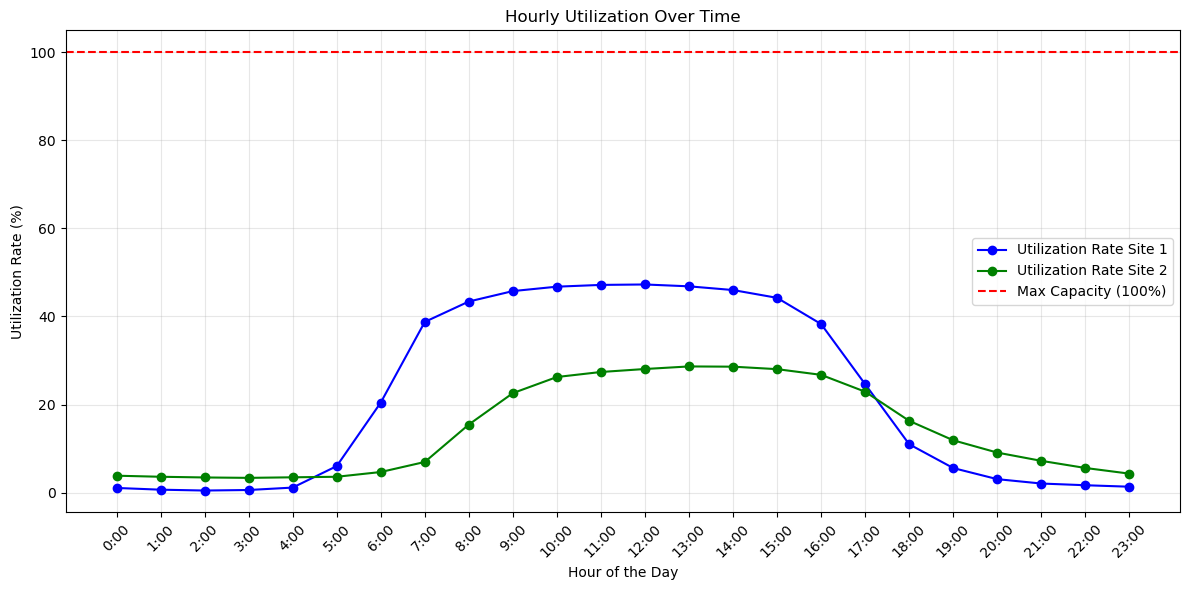

In [ ]:
# Calculate hourly utilization rates
hourly_usage_site1 = calculate_hourly_utilization_rate(1, data)
hourly_usage_site2 = calculate_hourly_utilization_rate(2, data)

# Plot the results
plot_hourly_utilization(hourly_usage_site1, hourly_usage_site2)

## 2. Average Session Duration

In [25]:
data['session_duration'] = (data['disconnectTime'] - data['connectionTime']).dt.total_seconds() / 60.0

average_duration = data['session_duration'].mean()

print(f"Average Duration of Charging Sessions: {average_duration:.2f} minutes")

Average Duration of Charging Sessions: 380.99 minutes


In [38]:
import pandas as pd

def calculate_average_session_duration(site_id, data):
    """
    Calculate the average session duration for a given charging site.

    Parameters:
        site_id (int or str): The ID of the charging site to analyze.
        data (pd.DataFrame): DataFrame containing charging session data with columns:
            - 'siteID': Site ID
            - 'connectionTime': Start time of the charging session (datetime)
            - 'disconnectTime': End time of the charging session (datetime)

    Returns:
        float: The average session duration for the given site in minutes.
    """
    site_id = str(site_id)  # Convert site_id to string
    # Filter data for the given siteID
    site_data = data[data['siteID'] == site_id].copy()

    # Ensure datetime columns are in datetime format
    site_data['connectionTime'] = pd.to_datetime(site_data['connectionTime'])
    site_data['disconnectTime'] = pd.to_datetime(site_data['disconnectTime'])

    # Calculate session duration (difference between disconnectTime and connectionTime)
    site_data['sessionDuration'] = (site_data['disconnectTime'] - site_data['connectionTime']).dt.total_seconds() / 60  # in minutes

    # Calculate the average session duration
    avg_session_duration = site_data['sessionDuration'].mean()

    return avg_session_duration

# Example usage:
avg_duration_site1 = calculate_average_session_duration(1, data)
avg_duration_site2 = calculate_average_session_duration(2, data)

print(f"Average session duration for Site 1: {avg_duration_site1:.2f} minutes")
print(f"Average session duration for Site 2: {avg_duration_site2:.2f} minutes")


Average session duration for Site 1: 410.84 minutes
Average session duration for Site 2: 336.69 minutes


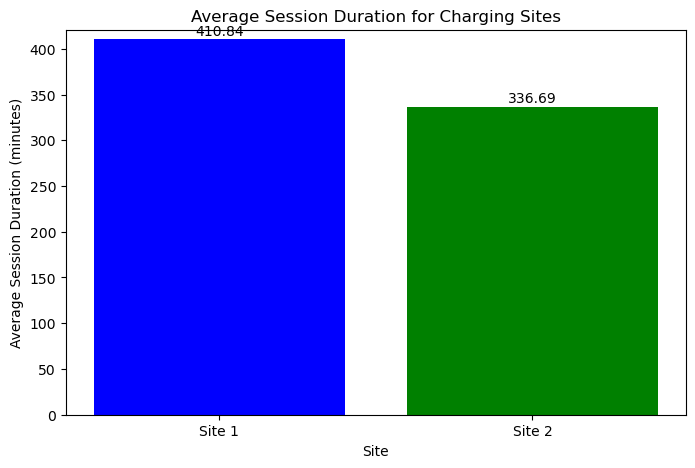

In [39]:
def plot_avg_session_duration(avg_durations, sites):
    """
    Plots the average session duration for different sites.

    Parameters:
        avg_durations (list): A list containing average session durations for each site.
        sites (list): A list of site names corresponding to the durations in avg_durations.
    """
    plt.figure(figsize=(8, 5))
    plt.bar(sites, avg_durations, color=['blue', 'green'])

    # Adding labels and title
    plt.xlabel('Site')
    plt.ylabel('Average Session Duration (minutes)')
    plt.title('Average Session Duration for Charging Sites')
    plt.ylim(0, max(avg_durations) + 10)  # Add some padding to the top of the bars

    # Display the value on top of each bar
    for i, v in enumerate(avg_durations):
        plt.text(i, v + 1, f'{v:.2f}', ha='center', va='bottom', fontsize=10)

    # Show the plot
    plt.show()

# Calculate the average session duration for both sites
avg_duration_site1 = calculate_average_session_duration(1, data)
avg_duration_site2 = calculate_average_session_duration(2, data)

# Prepare the data for plotting
avg_durations = [avg_duration_site1, avg_duration_site2]
sites = ['Site 1', 'Site 2']

# Call the plotting function
plot_avg_session_duration(avg_durations, sites)

In [40]:
# Calculate the average session duration for Site 1
avg_duration_site1 = calculate_average_session_duration(1, data)
print(f"Average session duration for Site 1: {avg_duration_site1:.2f} minutes")

# Calculate the average session duration for Site 2
avg_duration_site2 = calculate_average_session_duration(2, data)
print(f"Average session duration for Site 2: {avg_duration_site2:.2f} minutes")


Average session duration for Site 1: 410.84 minutes
Average session duration for Site 2: 336.69 minutes


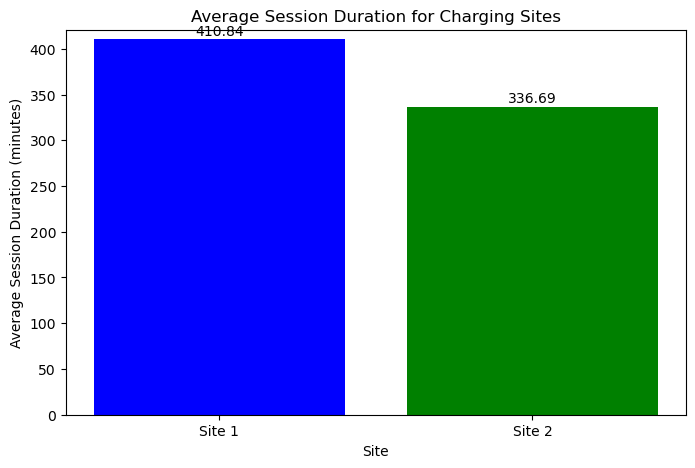

In [41]:
# Plot the average session duration for both sites
plot_avg_session_duration(avg_durations, sites)


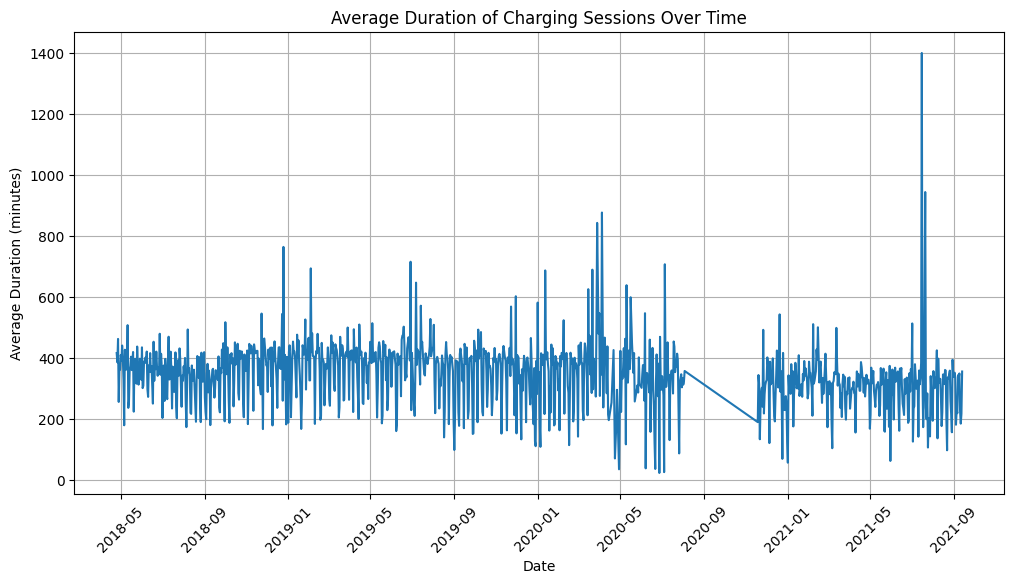

In [26]:
# Group by day and calculate the average duration for each day
data['date'] = data['connectionTime'].dt.date
average_duration_per_day = data.groupby('date')['session_duration'].mean().reset_index()

# Line plot of the average duration over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=average_duration_per_day, x='date', y='session_duration')
plt.title('Average Duration of Charging Sessions Over Time')
plt.xlabel('Date')
plt.ylabel('Average Duration (minutes)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Energy Delivered per Hour (WIP) -- current approach can be found in dev_Xiaofeng -> 2 descriptive analytics.ipynb

In [ ]:
# TODO's:
# merge KPI notebooks and finish hourly calculation of KPI's
# visualize calculated KPI's and interpret observable trends
# expand justifications
# optional: find references for selected KPI's